# Lab 9 Report: 

## Final Project Codebase

# Project Title: 

## EcoBirdNet: Bird Species Classifier

This notebook trains a CNN bird-species classifier using the preprocessed NumPy output files from the automated cropping workflow:

- `X.npy` = cropped, resized RGB bird images
- `y.npy` = integer class labels
- `class_names.npy` = bird species class names

The notebook is structured for Google Colab, where the three `.npy` files can be uploaded directly into `/content/` before training.


Adapted from the previous CNN image-classification workflow (Lab 4: Fashion-MNIST), but revised for RGB bird photographs, a smaller 16-class dataset, preprocessing outputs, and slide-ready figures.


**Group Members:**

Arthur Wang, Daniel Michel, Rasool Ray

## 1. Imports and Output Folder

In [1]:
# Core libraries
import os
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# PyTorch libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Dataset, Subset

# Torchvision tools
from torchvision.utils import make_grid
from torchvision import transforms

# Evaluation tools
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# Image loading
from PIL import Image

# Reproducibility
random.seed(55)
np.random.seed(55)
torch.manual_seed(55)

OUTPUT_DIR = Path("EcoBirdNet_project_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)
print("Output images will be saved to:", OUTPUT_DIR.resolve())

# Image loading for final Google Drive example image
from PIL import Image

Using device: cuda
Output images will be saved to: /content/EcoBirdNet_project_outputs


# Prepare Data:

## 2. Upload Preprocessed Cropping Outputs to Colab

Run this cell if the files are not already in `/content/`. Upload:

- `X.npy`
- `y.npy`
- `class_names.npy`

These files are the outputs from the cropping/resizing/slicing preprocessing step.


In [2]:
# Uncomment and run this cell to upload the three .npy files.
# After upload, they should appear in /content/.

# from google.colab import files
# uploaded = files.upload()

In [3]:
# To use a dataset from Google Drive, first mount your Google Drive:
from google.colab import drive
drive.mount('/content/drive')

# Then, update this path to your dataset's location in Google Drive, e.g.:
DATASET_ROOT = Path("/content/drive/MyDrive/EcoBirdNet")

# Project scope
NUM_CLASSES = 16
IMAGES_PER_CLASS = 50
IMAGE_SIZE = 96

# Optional: manually list the 16 bird species you want to use.
# These names must exactly match the folder names in DATASET_ROOT.
SELECTED_SPECIES = [
    # "Belted Kingfisher",
    # "Hooded Merganser",
    # "Pileated Woodpecker",
    # ...
]

print("Dataset root:", DATASET_ROOT)
print("Image size:", IMAGE_SIZE)
print("Target number of species:", NUM_CLASSES)
print("Approximate images per species:", IMAGES_PER_CLASS)

Mounted at /content/drive
Dataset root: /content/drive/MyDrive/EcoBirdNet
Image size: 96
Target number of species: 16
Approximate images per species: 50


## 3. Load Cropped, Resized, and Sliced Dataset

This replaces the older folder-based `ImageFolder` loading. The dataset is already represented as NumPy arrays, where each image has been cropped/sliced around the bird, resized to a consistent shape, and assigned a class label.


In [4]:
# File paths for Colab content folder
X_PATH = "/content/X.npy"
Y_PATH = "/content/y.npy"
CLASS_NAMES_PATH = "/content/class_names.npy"

# If running locally outside Colab, you may change these paths.
# X_PATH = "X.npy"
# Y_PATH = "y.npy"
# CLASS_NAMES_PATH = "class_names.npy"

# Load preprocessed cropped bird dataset
X = np.load(X_PATH)
y = np.load(Y_PATH)
class_names = np.load(CLASS_NAMES_PATH, allow_pickle=True)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of classes:", len(class_names))
print("Class names:")
for i, name in enumerate(class_names):
    print(f"{i}: {name}")

X shape: (944, 96, 96, 3)
y shape: (944,)
Number of classes: 16
Class names:
0: 008.Rhinoceros_Auklet
1: 010.Red_winged_Blackbird
2: 036.Northern_Flicker
3: 047.American_Goldfinch
4: 058.Pigeon_Guillemot
5: 060.Glaucous_winged_Gull
6: 067.Anna_Hummingbird
7: 069.Rufous_Hummingbird
8: 076.Dark_eyed_Junco
9: 079.Belted_Kingfisher
10: 089.Hooded_Merganser
11: 107.Common_Raven
12: 132.White_crowned_Sparrow
13: 143.Caspian_Tern
14: 186.Cedar_Waxwing
15: 188.Pileated_Woodpecker


## 4. Final Preprocessing for CNN Input

The uploaded `X.npy` array already contains the automated cropping, slicing, and resizing output. This cell completes the model-ready preprocessing by clipping pixel values, preserving RGB channels, converting images to PyTorch tensor format, and packaging the data for training.


In [5]:
# Ensure image data is stored as float32
X = X.astype(np.float32)

# Normalize if images are stored as 0-255 values
if X.max() > 1.0:
    X = X / 255.0

# Clip/slice values into a valid image range
X = np.clip(X, 0.0, 1.0)

# Keep display copy in N x H x W x C format
X_display = X.copy()

# PyTorch expects N x C x H x W
if X.ndim == 4 and X.shape[-1] == 3:
    X = np.transpose(X, (0, 3, 1, 2))

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)

NUM_CLASSES = len(class_names)
IMAGE_SIZE = X_tensor.shape[-1]
SELECTED_SPECIES = list(class_names)

print("Tensor image shape:", X_tensor.shape)
print("Tensor label shape:", y_tensor.shape)
print("Image size:", IMAGE_SIZE)
print("Number of classes:", NUM_CLASSES)
print("Total images:", len(X_tensor))
print("Pixel value range:", float(X_tensor.min()), "to", float(X_tensor.max()))

Tensor image shape: torch.Size([944, 3, 96, 96])
Tensor label shape: torch.Size([944])
Image size: 96
Number of classes: 16
Total images: 944
Pixel value range: 0.0 to 1.0


## 5. Train / Validation / Test Split

In [6]:
# Split selected data into training, validation, and testing sets.
# Approximate split: 70% train, 15% validation, 15% test.

# Custom dataset so augmentation can be applied only to training images
class BirdTensorDataset(Dataset):
    def __init__(self, X_tensor, y_tensor, transform=None):
        self.X_tensor = X_tensor
        self.y_tensor = y_tensor
        self.transform = transform

    def __len__(self):
        return len(self.X_tensor)

    def __getitem__(self, idx):
        image = self.X_tensor[idx]
        label = self.y_tensor[idx]

        if self.transform is not None:
            image = self.transform(image)

        return image, label


# Training augmentation helps because the dataset is small
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.RandomResizedCrop(size=IMAGE_SIZE, scale=(0.85, 1.0)),
    transforms.ToTensor()
])

# Validation and testing should not use random augmentation
eval_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])


# Stratified split by class label
indices = np.arange(len(y_tensor))
labels_np = y_tensor.numpy()

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.30,
    stratify=labels_np,
    random_state=55
)

validation_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    stratify=labels_np[temp_idx],
    random_state=55
)


# Separate datasets so training gets augmentation, validation/test do not
full_train_dataset = BirdTensorDataset(X_tensor, y_tensor, transform=train_transform)
full_eval_dataset = BirdTensorDataset(X_tensor, y_tensor, transform=eval_transform)

train_dataset = Subset(full_train_dataset, train_idx)
validation_dataset = Subset(full_eval_dataset, validation_idx)
test_dataset = Subset(full_eval_dataset, test_idx)

batchsize = 32

train_loader = DataLoader(train_dataset, batch_size=batchsize, shuffle=True, num_workers=0)
validation_loader = DataLoader(validation_dataset, batch_size=batchsize, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batchsize, shuffle=False, num_workers=0)

print("Training images:", len(train_dataset))
print("Validation images:", len(validation_dataset))
print("Testing images:", len(test_dataset))

Training images: 660
Validation images: 142
Testing images: 142


## 6. Slide-Ready Sample Images

This cell displays examples from the cropped, resized, and clipped/sliced image dataset. The saved output can be used directly in the slide presentation.


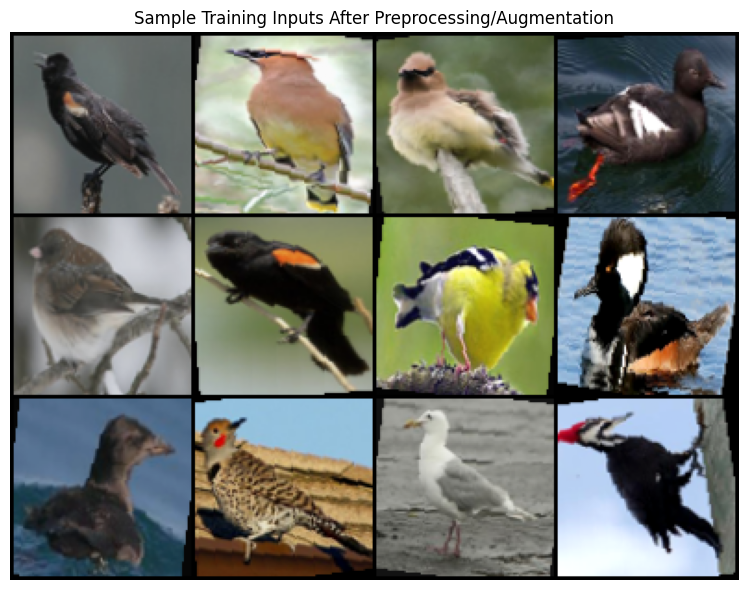

In [7]:
# Show a small grid of cropped/resized training images.
images, labels = next(iter(train_loader))

# Images are already in 0-1 range, so no unnormalization is needed.
display_images = images[:12].cpu()
grid = make_grid(display_images, nrow=4)

plt.figure(figsize=(8, 6))
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.title("Sample Training Inputs After Preprocessing/Augmentation")
plt.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sample_training_inputs.png", dpi=300)
plt.show()

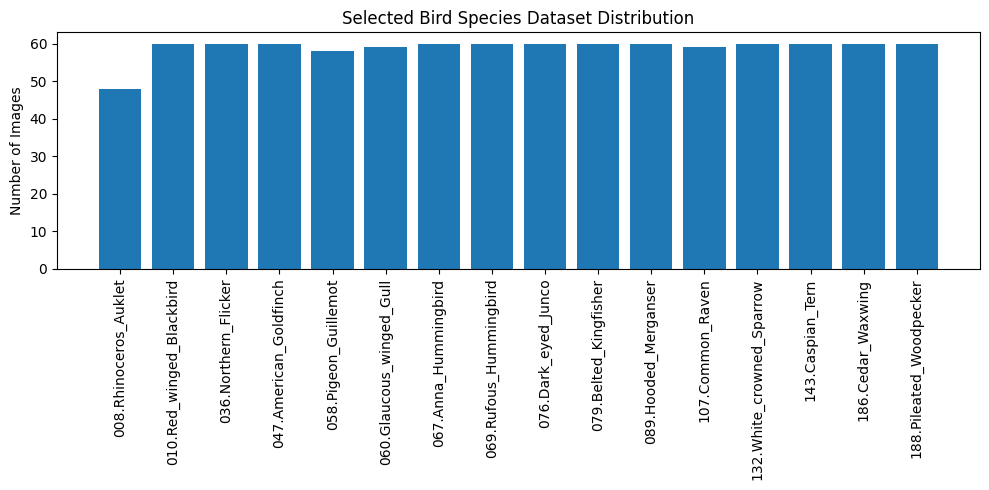

In [8]:
# Class distribution plot for the selected subset
unique_labels, label_counts = np.unique(y, return_counts=True)

plt.figure(figsize=(10, 5))
plt.bar([class_names[i] for i in unique_labels], label_counts)
plt.xticks(rotation=90)
plt.ylabel("Number of Images")
plt.title("Selected Bird Species Dataset Distribution")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "class_distribution.png", dpi=300)
plt.show()

# Define Model:

## 7. Proposed CNN Architecture

This architecture follows a standard CNN image-classification structure, adapted for 96 x 96 RGB bird images and a 16-class output.


In [9]:
class BirdCNNModel(nn.Module):
    def __init__(self, num_classes=16):
        super(BirdCNNModel, self).__init__()

        self.features = nn.Sequential(
            # Input: N x 3 x 96 x 96
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 96 -> 48

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 48 -> 24

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 24 -> 12

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 12 -> 6

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = BirdCNNModel(num_classes=NUM_CLASSES).to(device)
print(model)

BirdCNNModel(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tr

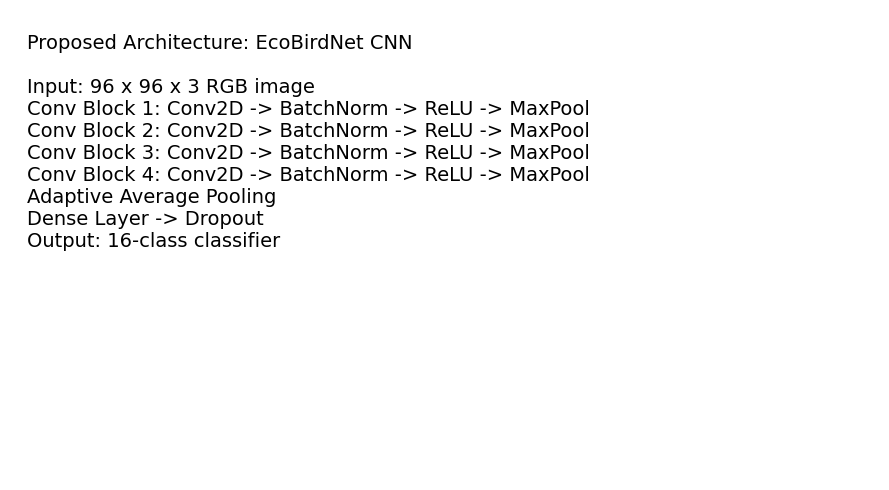

In [10]:
architecture_lines = [
    "Proposed Architecture: EcoBirdNet CNN",
    "",
    "Input: 96 x 96 x 3 RGB image",
    "Conv Block 1: Conv2D -> BatchNorm -> ReLU -> MaxPool",
    "Conv Block 2: Conv2D -> BatchNorm -> ReLU -> MaxPool",
    "Conv Block 3: Conv2D -> BatchNorm -> ReLU -> MaxPool",
    "Conv Block 4: Conv2D -> BatchNorm -> ReLU -> MaxPool",
    "Adaptive Average Pooling",
    "Dense Layer -> Dropout",
    "Output: 16-class classifier"
]

plt.figure(figsize=(9, 5))
plt.axis("off")
plt.text(0.02, 0.95, "\n".join(architecture_lines),
         va="top", ha="left", fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "proposed_architecture_summary.png", dpi=300)
plt.show()

# Define Hyperparameters:

## 8. Training Setup

In [11]:
learning_rate = 0.001
epochs = 100

# Class-weighted loss can help if some classes have fewer images
class_counts = np.bincount(y_tensor.numpy(), minlength=NUM_CLASSES)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

loss_func = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=8
)

print("Training Hyperparameters")
print(f"Learning rate: {learning_rate}")
print(f"Batch size: {batchsize}")
print(f"Epochs: {epochs}")
print("Optimizer: Adam with weight decay")
print("Loss function: Weighted CrossEntropyLoss")
print("Scheduler: ReduceLROnPlateau")

Training Hyperparameters
Learning rate: 0.001
Batch size: 32
Epochs: 100
Optimizer: Adam with weight decay
Loss function: Weighted CrossEntropyLoss
Scheduler: ReduceLROnPlateau


# Identify Tracked Values & Train Model:

## 9. Training Loop

Epoch-by-epoch training loss and validation accuracy are printed during training.


In [12]:
train_loss_epoch_list = []
train_accuracy_list = []
validation_accuracy_list = []
epoch_list = []

best_validation_accuracy = 0.0
best_model_path = OUTPUT_DIR / "EcoBirdNet_best_model_state_dict.pt"

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = loss_func(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    average_train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * train_correct / train_total

    train_loss_epoch_list.append(average_train_loss)
    train_accuracy_list.append(train_accuracy)

    # Validation accuracy
    model.eval()
    validation_correct = 0
    validation_total = 0

    with torch.no_grad():
        for images, labels in validation_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            validation_total += labels.size(0)
            validation_correct += (predicted == labels).sum().item()

    validation_accuracy = 100 * validation_correct / validation_total
    validation_accuracy_list.append(validation_accuracy)
    epoch_list.append(epoch + 1)

    scheduler.step(validation_accuracy)

    # Save best model based on validation accuracy
    if validation_accuracy > best_validation_accuracy:
        best_validation_accuracy = validation_accuracy
        torch.save(model.state_dict(), best_model_path)

    print(f"Epoch [{epoch + 1}/{epochs}], "
          f"Loss: {average_train_loss:.4f}, "
          f"Train Accuracy: {train_accuracy:.2f}%, "
          f"Validation Accuracy: {validation_accuracy:.2f}%")

print(f"Best Validation Accuracy: {best_validation_accuracy:.2f}%")
print("Best model saved to:", best_model_path)

Epoch [1/100], Loss: 2.6786, Train Accuracy: 11.67%, Validation Accuracy: 7.04%
Epoch [2/100], Loss: 2.4903, Train Accuracy: 19.85%, Validation Accuracy: 19.01%
Epoch [3/100], Loss: 2.3694, Train Accuracy: 21.97%, Validation Accuracy: 24.65%
Epoch [4/100], Loss: 2.3500, Train Accuracy: 22.42%, Validation Accuracy: 23.94%
Epoch [5/100], Loss: 2.2131, Train Accuracy: 28.79%, Validation Accuracy: 27.46%
Epoch [6/100], Loss: 2.1627, Train Accuracy: 28.33%, Validation Accuracy: 31.69%
Epoch [7/100], Loss: 2.1080, Train Accuracy: 30.00%, Validation Accuracy: 32.39%
Epoch [8/100], Loss: 2.0573, Train Accuracy: 33.94%, Validation Accuracy: 24.65%
Epoch [9/100], Loss: 2.0675, Train Accuracy: 33.03%, Validation Accuracy: 28.87%
Epoch [10/100], Loss: 1.9608, Train Accuracy: 36.36%, Validation Accuracy: 35.92%
Epoch [11/100], Loss: 1.8753, Train Accuracy: 37.58%, Validation Accuracy: 42.96%
Epoch [12/100], Loss: 1.8302, Train Accuracy: 40.76%, Validation Accuracy: 42.96%
Epoch [13/100], Loss: 1.77

# Visualize & Evaluate Model:

## 10. Slide-Ready Training Curves

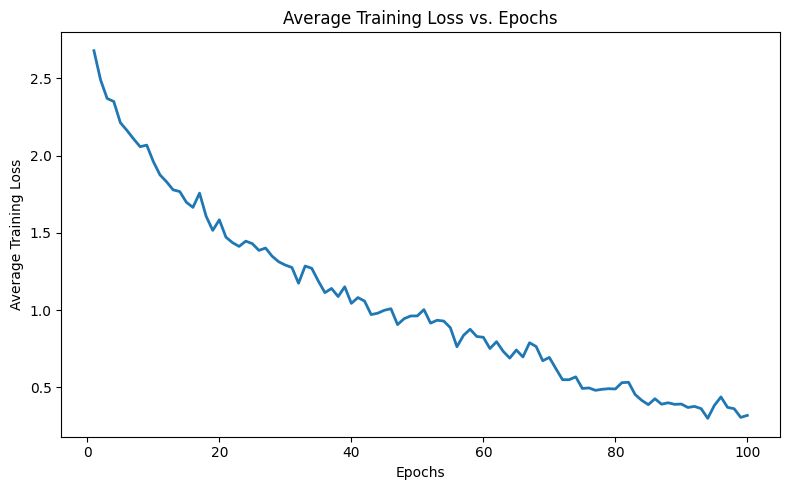

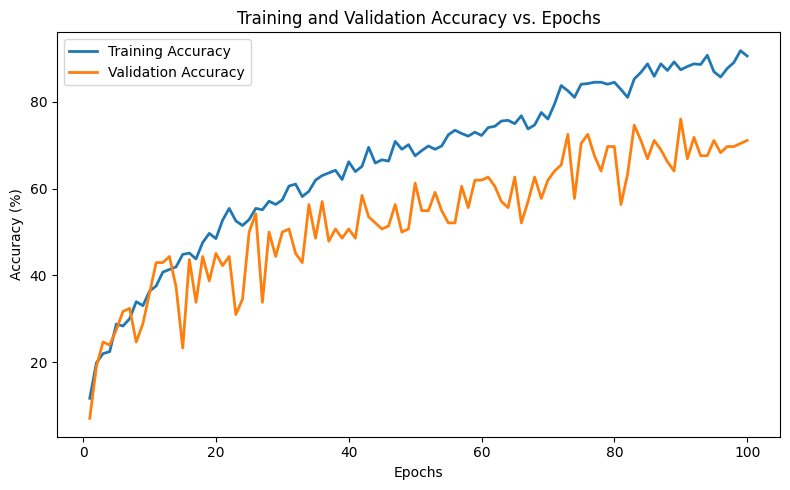

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(epoch_list, train_loss_epoch_list, linewidth=2)
plt.title("Average Training Loss vs. Epochs")
plt.ylabel("Average Training Loss")
plt.xlabel("Epochs")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_loss_curve.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epoch_list, train_accuracy_list, linewidth=2, label="Training Accuracy")
plt.plot(epoch_list, validation_accuracy_list, linewidth=2, label="Validation Accuracy")
plt.title("Training and Validation Accuracy vs. Epochs")
plt.ylabel("Accuracy (%)")
plt.xlabel("Epochs")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_validation_accuracy_curve.png", dpi=300)
plt.show()

## 11. Test Accuracy and Class-Level Evaluation

In [14]:
# Load best validation model before final testing
model.load_state_dict(torch.load(OUTPUT_DIR / "EcoBirdNet_best_model_state_dict.pt", map_location=device))
model.eval()

all_predictions = []
all_true_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_true_labels.extend(labels.cpu().numpy())

all_predictions = np.array(all_predictions)
all_true_labels = np.array(all_true_labels)

test_accuracy = 100 * np.mean(all_predictions == all_true_labels)
print(f"Test Accuracy: {test_accuracy:.2f}%")

for i, species_name in enumerate(class_names):
    class_indices = (all_true_labels == i)

    if class_indices.sum() > 0:
        class_accuracy = 100 * np.mean(all_predictions[class_indices] == all_true_labels[class_indices])
        print(f"Accuracy of {species_name}: {class_accuracy:.1f}%")
    else:
        print(f"No test samples for {species_name}")

Test Accuracy: 69.01%
Accuracy of 008.Rhinoceros_Auklet: 71.4%
Accuracy of 010.Red_winged_Blackbird: 77.8%
Accuracy of 036.Northern_Flicker: 33.3%
Accuracy of 047.American_Goldfinch: 88.9%
Accuracy of 058.Pigeon_Guillemot: 33.3%
Accuracy of 060.Glaucous_winged_Gull: 55.6%
Accuracy of 067.Anna_Hummingbird: 66.7%
Accuracy of 069.Rufous_Hummingbird: 88.9%
Accuracy of 076.Dark_eyed_Junco: 44.4%
Accuracy of 079.Belted_Kingfisher: 55.6%
Accuracy of 089.Hooded_Merganser: 66.7%
Accuracy of 107.Common_Raven: 77.8%
Accuracy of 132.White_crowned_Sparrow: 77.8%
Accuracy of 143.Caspian_Tern: 100.0%
Accuracy of 186.Cedar_Waxwing: 88.9%
Accuracy of 188.Pileated_Woodpecker: 77.8%


<Figure size 1000x1000 with 0 Axes>

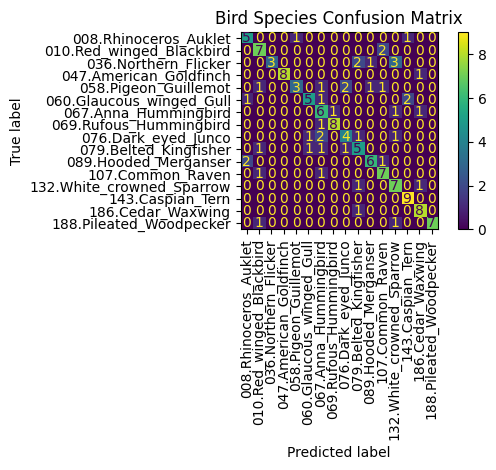

In [15]:
# Confusion matrix for slide/report use
cm = confusion_matrix(all_true_labels, all_predictions, labels=np.arange(NUM_CLASSES))

plt.figure(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation=90, values_format="d")
plt.title("Bird Species Confusion Matrix")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=300)
plt.show()

## 12. Save Model

In [16]:
torch.save(model.state_dict(), OUTPUT_DIR / "EcoBirdNet_final_model_state_dict.pt")
np.save(OUTPUT_DIR / "class_names.npy", class_names)

print("Saved final model to:", OUTPUT_DIR / "EcoBirdNet_final_model_state_dict.pt")
print("Best model already saved to:", OUTPUT_DIR / "EcoBirdNet_best_model_state_dict.pt")
print("Saved class names to:", OUTPUT_DIR / "class_names.npy")

Saved final model to: EcoBirdNet_project_outputs/EcoBirdNet_final_model_state_dict.pt
Best model already saved to: EcoBirdNet_project_outputs/EcoBirdNet_best_model_state_dict.pt
Saved class names to: EcoBirdNet_project_outputs/class_names.npy


## 13. Example Input Image and Identification

This final cell displays one example input image from the test set, then prints the true species label, predicted species identification, and model confidence.


Example image path: /content/drive/MyDrive/EcoBirdNet/188.Pileated_Woodpecker/Pileated_Woodpecker_0026_180078.jpg


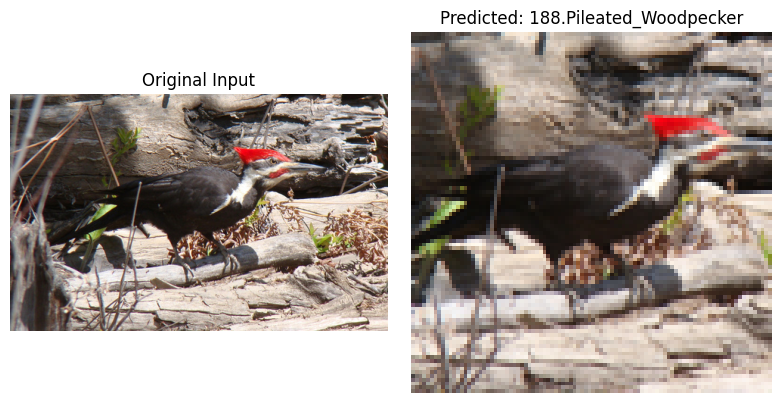

Classifying image from: /content/drive/MyDrive/EcoBirdNet/188.Pileated_Woodpecker/Pileated_Woodpecker_0026_180078.jpg
True species: 188.Pileated_Woodpecker
Predicted species: 188.Pileated_Woodpecker
Confidence: 62.42%


In [17]:
model.load_state_dict(torch.load(OUTPUT_DIR / "EcoBirdNet_best_model_state_dict.pt", map_location=device))
model.eval()

# Load the image from the specified path
# Change this path to the sample image you want to classify at the end of the notebook.

# Examples:

#EXAMPLE_IMAGE_PATH = "/content/drive/MyDrive/EcoBirdNet/010.Red_winged_Blackbird/Red_Winged_Blackbird_0020_4050.jpg"
#EXAMPLE_IMAGE_PATH = "/content/drive/MyDrive/EcoBirdNet/079.Belted_Kingfisher/Belted_Kingfisher_0028_70358.jpg"
#EXAMPLE_IMAGE_PATH = "/content/drive/MyDrive/EcoBirdNet/107.Common_Raven/Common_Raven_0001_101213.jpg"
#EXAMPLE_IMAGE_PATH = "/content/drive/MyDrive/EcoBirdNet/047.American_Goldfinch/American_Goldfinch_0032_31922.jpg"
#EXAMPLE_IMAGE_PATH = "/content/drive/MyDrive/EcoBirdNet/089.Hooded_Merganser/Hooded_Merganser_0028_79061.jpg"
#EXAMPLE_IMAGE_PATH = "/content/drive/MyDrive/EcoBirdNet/067.Anna_Hummingbird/Anna_Hummingbird_0037_56587.jpg"
EXAMPLE_IMAGE_PATH = "/content/drive/MyDrive/EcoBirdNet/188.Pileated_Woodpecker/Pileated_Woodpecker_0026_180078.jpg"

print("Example image path:", EXAMPLE_IMAGE_PATH)

# Load and preprocess the image
"""
pil_image = Image.open(EXAMPLE_IMAGE_PATH).convert("RGB")
pil_image = pil_image.resize((IMAGE_SIZE, IMAGE_SIZE))
image_np = np.array(pil_image).astype(np.float32) / 255.0
"""

# Prepare for model input (N x C x H x W)
def preprocess_example_image(image_path, image_size=96):
    original_image = Image.open(image_path).convert("RGB")

    # Center crop/slice to square
    width, height = original_image.size
    crop_size = min(width, height)

    left = (width - crop_size) // 2
    top = (height - crop_size) // 2
    right = left + crop_size
    bottom = top + crop_size

    cropped_image = original_image.crop((left, top, right, bottom))

    # Resize to CNN input size
    resized_image = cropped_image.resize((image_size, image_size))

    # Convert to 0-1 array and clip
    image_np = np.array(resized_image).astype(np.float32) / 255.0
    image_np = np.clip(image_np, 0.0, 1.0)

    # Convert to N x C x H x W tensor
    input_tensor = torch.tensor(image_np).permute(2, 0, 1).unsqueeze(0)

    return original_image, image_np, input_tensor


original_image, processed_image_np, input_image_tensor = preprocess_example_image(
    EXAMPLE_IMAGE_PATH,
    image_size=IMAGE_SIZE
)

input_image_tensor = input_image_tensor.to(device)

with torch.no_grad():
    output = model(input_image_tensor)
    probabilities = torch.softmax(output, dim=1)
    confidence, predicted_class = torch.max(probabilities, 1)

predicted_name = class_names[predicted_class.item()]
confidence_percent = confidence.item() * 100

true_name = Path(EXAMPLE_IMAGE_PATH).parent.name

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(original_image)
plt.axis("off")
plt.title("Original Input")

plt.subplot(1, 2, 2)
plt.imshow(processed_image_np)
plt.axis("off")
plt.title(f"Predicted: {predicted_name}")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "example_input_prediction.png", dpi=300)
plt.show()

print("Classifying image from:", EXAMPLE_IMAGE_PATH)
print("True species:", true_name)
print("Predicted species:", predicted_name)
print(f"Confidence: {confidence_percent:.2f}%")

## Suggested Slide Outputs

After running the notebook, useful presentation figures will be saved in `EcoBirdNet_project_outputs/`:

- `sample_cropped_resized_bird_inputs.png`
- `class_distribution.png`
- `proposed_architecture_summary.png`
- `training_loss_curve.png`
- `validation_accuracy_curve.png`
- `confusion_matrix.png`
- `example_input_prediction.png`


# 1. What is our data?


In [ ]:
# We use an online bird image dataset that originally contains 200 bird species and about 11,788 images.
# For our project, we selected 16 bird species that are common in Seattle or the Northwestern region. The dataset is stored as X.npy, y.npy, and class_names.npy.
# Each image is cropped, resized, clipped, normalized, and converted into a 96 × 96 × 3 RGB tensor.
# We split the data into training, validation, and test sets, and we apply data augmentation during training to improve generalization.
# The dataset has some class imbalance, so we use weighted cross-entropy loss during training.


# 2. What task are we solving?

In [ ]:
# Our task is a 16-class image classification problem.
# Given a preprocessed RGB image of a bird, the neural network predicts which of the 16 bird species it belongs to.
# The significance of this task is that it can support local bird enthusiasts, ecological monitoring, and bird-identification users in recognizing common Northwestern bird species.
# We also built a prototype website or app to let users experience the bird-identification model.
# We evaluate the model using validation accuracy, test accuracy, class-level accuracy ,confusion matrix
# According to our results, the best validation accuracy is 73.94%, and the test accuracy is 62.68%.
# This shows that the model learned useful visual features, but its generalization to unseen images is still limited.

# 3. What model and evaluation plan will we use?

In [ ]:
# The input to our model is a 96 × 96 × 3 RGB bird image. The output is a 16-class prediction, where each output represents one bird species.
# We use a CNN architecture with four convolutional blocks. Each block includes Conv2D → BatchNorm → ReLU → MaxPool.
# After the convolutional blocks, the model uses Adaptive average pooling → dense layer → dropout → 16-class output.
# The model is trained with Optimizer: Adam; Learning rate: 0.001; Epochs: 100; Loss function: weighted cross-entropy; Scheduler: ReduceLROnPlateau
# We evaluate the model using validation accuracy during training and test accuracy after training.
# We also examine the confusion matrix and class-level accuracy to understand which bird species are confused.
# In addition, we can use online bird images as extra qualitative tests, but our main evaluation is based on the validation and test sets.

## Understanding the Data

```python
# Initial data exploration plan

# 1. Load the dataset
# Depending on the dataset format, we may load image paths and labels from:
# - CSV file
# - folder structure
# - metadata file

# Example:
# import pandas as pd
# data = pd.read_csv("metadata.csv")
# data.head()

# 2. Check the number of samples
# data.shape

# 3. Check the label distribution
# data["species"].value_counts()

# 4. Check for missing values
# data.isnull().sum()

# 5. Visualize sample images
# import matplotlib.pyplot as plt
# from PIL import Image

# 6. Understand image size and format
# We need to check if images have different sizes and whether preprocessing is needed.
```

### Data Description

The dataset for our project is based on bird images and their corresponding species labels. Each data point is likely an image of a bird, and the target variable is the bird species. The main goal is to train a model that can identify the correct species based on visual features.

Possible features in the dataset include:

- Bird image
- Species label
- File name or image ID
- Possible metadata such as location, habitat, or observation source
- Possible train/test split information

Since this is an image-based dataset, the raw data itself is not a normal table of numerical variables. Instead, the most important information comes from visual patterns in the images, such as:

- Color
- Shape
- Beak size
- Wing pattern
- Body posture
- Background environment

### Initial Observations

Before building the model, we need to understand the dataset carefully. Some important questions include:

1. **How many bird species are included?**  
   This matters because the difficulty of the classification task increases when there are more categories.

2. **How many images are available for each species?**  
   If some species have many images while others have very few, the model may become biased toward the common species.

3. **Are the images balanced or imbalanced?**  
   Class imbalance may require data augmentation, weighted loss, or careful evaluation metrics.

4. **Are the images clean?**  
   Some images may be blurry, too dark, contain multiple birds, or show birds far away from the camera.

5. **Are there background biases?**  
   The model might learn the background instead of the bird itself. For example, if one species mostly appears near water and another mostly appears in forests, the model may rely too much on the environment.

### Data Cleaning and Preprocessing Plan

We plan to preprocess the data by:

- Resizing images to a fixed size, such as 224 x 224 pixels
- Normalizing pixel values
- Removing corrupted or unreadable images
- Checking missing or incorrect labels
- Splitting the dataset into training, validation, and test sets
- Applying data augmentation, such as:
  - Random horizontal flip
  - Random rotation
  - Random crop
  - Color jitter
  - Brightness and contrast adjustment

Data augmentation is important because it can help the model generalize better and reduce overfitting.

---

## Understanding the Task

```python
# Machine learning task definition

# Task type:
# Image classification

# Input:
# Bird images

# Output:
# Bird species label

# Possible models:
# 1. Baseline CNN
# 2. Transfer learning model such as ResNet, EfficientNet, or MobileNet
# 3. Fine-tuned pretrained image classification model

# Evaluation metrics:
# - Accuracy
# - Precision
# - Recall
# - F1-score
# - Confusion matrix
```

### Task Description

The main task of our final project is to classify bird species from images. This is a supervised learning problem because each image has a known label. The model will learn patterns from labeled training images and then predict the species of unseen bird images.

This task is meaningful because automatic bird recognition can support ecological research and environmental monitoring. Human identification of bird species can take time and requires expert knowledge. A machine learning model could help identify species more quickly and support biodiversity studies.

### Research Question

Our main research question is:

**Can a machine learning model accurately classify bird species from image data, and what visual or data-related factors affect its performance?**

More specifically, we want to explore:

- How accurately can the model classify different bird species?
- Which species are easier or harder to classify?
- Does class imbalance affect model performance?
- Do background, image quality, and visual similarity between species create errors?
- Can transfer learning improve performance compared to a simple baseline model?

### Prediction Target

The prediction target is the bird species label.

For example:

- Input: an image of a bird
- Output: predicted species name or species ID

### Type of Machine Learning Problem

This is a **multi-class image classification** problem.

If there are many species, the model needs to choose one correct class from multiple possible bird species.

### Why This Task Is Challenging

This task may be challenging for several reasons:

1. **Visual similarity between species**  
   Some bird species look very similar, especially if they have similar colors or body shapes.

2. **Different poses and angles**  
   Birds may appear from different viewpoints, such as flying, standing, or partially hidden.

3. **Background noise**  
   The background may include trees, water, sky, grass, or human-made objects. These may distract the model.

4. **Lighting differences**  
   Images may be taken under different lighting conditions, which can affect color and texture.

5. **Class imbalance**  
   Some species may have more images than others, causing the model to perform better on common species and worse on rare species.

### Evaluation Plan

We plan to evaluate the model using several metrics:

- **Accuracy**: overall percentage of correct predictions
- **Precision**: how many predicted labels are actually correct
- **Recall**: how many true examples of a species are correctly found
- **F1-score**: balance between precision and recall
- **Confusion matrix**: shows which species are often confused with each other

Accuracy alone may not be enough if the dataset is imbalanced. Therefore, F1-score and confusion matrix will be important for understanding model performance across different species.

---

## Developing an initial plan for your project

```python
# Initial project workflow

# Step 1: Load and inspect the dataset
# Step 2: Clean the data and remove corrupted images
# Step 3: Explore class distribution
# Step 4: Visualize sample images from different species
# Step 5: Split data into train, validation, and test sets
# Step 6: Build a baseline model
# Step 7: Train a transfer learning model
# Step 8: Evaluate the model
# Step 9: Analyze errors using confusion matrix
# Step 10: Write final report and prepare presentation
```

### Project Plan

Our project will follow a structured workflow. First, we will understand and clean the dataset. Then we will build a simple baseline model. After that, we will try a stronger model using transfer learning. Finally, we will evaluate the results and analyze the model’s errors.

### Step 1: Data Loading and Exploration

We will first load the dataset and inspect its structure. We need to understand how the images and labels are organized.

Important tasks include:

- Check how many images are in the dataset
- Check how many species are included
- Count the number of images per species
- Visualize sample images
- Check whether any images are corrupted
- Check whether labels are missing or inconsistent

This step is important because the quality of the dataset will strongly affect the final model performance.

### Step 2: Data Preprocessing

After understanding the dataset, we will preprocess the images.

Our preprocessing plan includes:

- Resize all images to a consistent size
- Normalize pixel values
- Convert labels into numerical format
- Split the data into training, validation, and testing sets
- Apply data augmentation to the training set

We plan to use data augmentation because it can make the model more robust. For example, if the model sees birds from slightly different angles or lighting conditions during training, it may perform better on new images.

### Step 3: Baseline Model

We will first build a simple baseline model. The baseline could be a small convolutional neural network, or a simple pretrained model without much fine-tuning.

The purpose of the baseline is to create a reference point. Later, we can compare more advanced models against this baseline.

Possible baseline model:

- Simple CNN with a few convolutional layers
- Pretrained MobileNet or ResNet used as a feature extractor

Baseline evaluation:

- Training accuracy
- Validation accuracy
- Test accuracy
- F1-score
- Confusion matrix

### Step 4: Improved Model with Transfer Learning

After building the baseline model, we plan to use transfer learning. Transfer learning is useful because pretrained models have already learned general visual features from large image datasets.

Possible models include:

- ResNet
- EfficientNet
- MobileNet
- VGG

We may start with a pretrained model and replace the final classification layer with a new layer for our bird species labels. Then we can fine-tune part of the model on our bird dataset.

This approach may improve performance because bird image classification requires recognizing detailed visual features, and pretrained image models are usually good at extracting shapes, colors, and textures.

### Step 5: Error Analysis

After training the model, we will analyze its mistakes.

We will use:

- Confusion matrix
- Misclassified image examples
- Class-level precision, recall, and F1-score

This analysis will help us understand:

- Which species are often confused
- Whether rare species have worse performance
- Whether image quality affects predictions
- Whether the model is relying too much on background information

This step is important because the goal is not only to get a high accuracy score, but also to understand the model’s limitations.

### Step 6: Final Report and Presentation

For the final report, we will explain:

- The dataset and task
- Why bird classification matters
- Data preprocessing steps
- Models we tried
- Evaluation results
- Error analysis
- Limitations
- Possible future improvements

For the final presentation, we will include:

- Project motivation
- Example images from the dataset
- Model workflow
- Results and visualizations
- Confusion matrix
- Key findings
- Challenges and next steps

### Potential Challenges

There are several possible challenges in this project:

1. **Large image dataset**  
   Training on many images may take a long time and require GPU resources.

2. **Class imbalance**  
   Some species may have fewer images, which can reduce model performance for those classes.

3. **Similar-looking species**  
   Some birds may be visually similar, making classification difficult.

4. **Overfitting**  
   The model may perform well on training data but poorly on new images.

5. **Data quality issues**  
   Some images may be blurry, mislabeled, or contain multiple birds.

### Possible Solutions

To handle these challenges, we plan to:

- Use data augmentation to reduce overfitting
- Use transfer learning to improve model performance
- Use validation data to monitor overfitting
- Use class weights if the dataset is imbalanced
- Analyze the confusion matrix to understand common errors
- Try different model architectures if time allows

### Expected Outcome

By the end of the project, we expect to have a working bird species classification model. We hope the model can achieve reasonable accuracy and provide useful insights into which species are easy or difficult to classify.

More importantly, we want to understand the strengths and limitations of using machine learning for ecological image recognition. Even if the model is not perfect, the error analysis can show us how data quality, class imbalance, and visual similarity affect the results.

### Broader Impact

This project has a connection to ecological monitoring and biodiversity research. Bird species are important indicators of environmental health. A model that can automatically recognize birds from images may help researchers, conservationists, and citizen scientists process large amounts of observation data.

However, we also need to be careful about the limitations of the model. If the model performs poorly on rare species or certain environments, it may create biased results. Therefore, responsible evaluation is important before using such a model in real ecological decision-making.

---